## 경로 설정 (레포 공통)

이 셀은 레포 어디에서 노트북을 열어도 `data/` 폴더를 자동으로 찾아 **상대경로 기반**으로 경로를 지정한다.
- `data/raw` 원자료 → `data/interim` 중간 자료 → `data/processed` 최종본, 그림·표는 `outputs/`에 저장한다.
- 노트북은 레포 안 어느 위치에서 실행해도 되지만, 레포 폴더 구조(`data/`, `src/`, `outputs/`)를 바꾸지 않아야 한다.

In [1]:
from pathlib import Path
ROOT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "data" / "raw").exists())
RAW = ROOT / "data" / "raw"
INTERIM = ROOT / "data" / "interim"
PROCESSED = ROOT / "data" / "processed"
FIG_DIR = ROOT / "outputs" / "figures"
TAB_DIR = ROOT / "outputs" / "tables"
for _d in (INTERIM, PROCESSED, FIG_DIR, TAB_DIR):
    _d.mkdir(parents=True, exist_ok=True)
print("프로젝트 루트 폴더:", ROOT.name)

프로젝트 루트 폴더: BAF-26-2-finance_2


# 병합패널 다중공선성·ICR변환 EDA

## 목적

1. **다중공선성** — 최종 회귀에 들어갈 변수(사전노출도, 사전현금여력, 원자재충격)를 같이 넣었을 때 계수 해석이 불안정해질 정도로 서로 겹치는지
2. **ICR 변환 방식 결정** — 원자료 / winsorize(1%/99%) / asinh 세 가지 후보의 분포를 비교해서, 어느 쪽을 본분석에 쓸지 판단할 근거를 만든다

**긴축기·평시 두 트랙을 각각 따로 확인한다.**

### 참고
- statsmodels VIF: https://www.statsmodels.org/stable/generated/statsmodels.stats.outliers_influence.variance_inflation_factor.html


## 1. 데이터 로드

In [2]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Markdown
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

for f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "Pretendard", "Noto Sans CJK KR"]:
    try:
        mpl.font_manager.findfont(f, fallback_to_default=False)
        mpl.rcParams["font.family"] = f
        break
    except Exception:
        pass
mpl.rcParams["axes.unicode_minus"] = False

# "2. EDA/" 폴더에서 실행하는 것을 기준으로 상대경로를 잡음
BASE = PROCESSED
p_tight = BASE / "재무_원자재_병합패널.csv"
p_calm  = BASE / "평시_재무_원자재_병합패널.csv"

for label, p in [("긴축기", p_tight), ("평시", p_calm)]:
    if not p.exists():
        raise FileNotFoundError(f"{label} 병합패널을 못 찾음: {p.resolve()}")

tight = pd.read_csv(p_tight, encoding="utf-8-sig")
calm  = pd.read_csv(p_calm,  encoding="utf-8-sig")

print("긴축기:", p_tight, tight.shape, "| 연도", tight["연도"].min(), "~", tight["연도"].max())
print("평시  :", p_calm,  calm.shape,  "| 연도", calm["연도"].min(), "~", calm["연도"].max())


긴축기: <repo>\data\processed\재무_원자재_병합패널.csv (240, 16) | 연도 2018 ~ 2023
평시  : <repo>\data\processed\평시_재무_원자재_병합패널.csv (200, 16) | 연도 2015 ~ 2019


## 2. 상관관계 분석

최종 회귀에 들어갈 후보 변수들:
- `사전노출도(%)`, `사전현금여력(%)` — 업종별 고정값(사전기간 평균)
- `shock_baseline_1111only`, `shock_extended_1111_1119` — 원자재충격(업종×연도로 변동)
- `ICR` — 종속변수

이 변수들 사이의 피어슨 상관계수를 확인한다. 패널 전체(업종×연도) 행 단위로 계산하므로, 업종별 고정값(사전노출도·현금여력)은 같은 값이 여러 행에 반복된다는 점을 고려해서 읽어야 한다.

=== 긴축기 트랙 상관행렬 ===


,ICR,사전노출도(%),사전현금여력(%),shock_baseline_1111only,shock_extended_1111_1119
ICR,1.0000,-0.3055,0.3557,0.0593,0.0596
사전노출도(%),-0.3055,1.0000,-0.5342,-0.0280,-0.0274
사전현금여력(%),0.3557,-0.5342,1.0000,-0.0372,-0.0370
shock_baseline_1111only,0.0593,-0.0280,-0.0372,1.0000,0.9998
shock_extended_1111_1119,0.0596,-0.0274,-0.0370,0.9998,1.0000


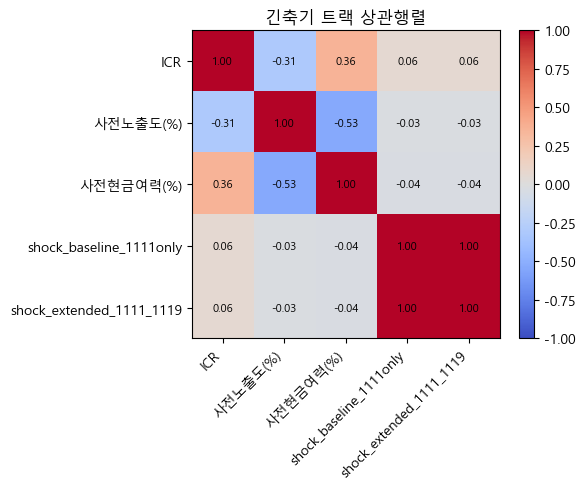

In [3]:
corr_vars = ["ICR", "사전노출도(%)", "사전현금여력(%)",
             "shock_baseline_1111only", "shock_extended_1111_1119"]

def corr_report(df, label):
    corr = df[corr_vars].corr()
    print(f"=== {label} 트랙 상관행렬 ===")
    display(corr.round(4))

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_xticks(range(len(corr_vars))); ax.set_xticklabels(corr_vars, rotation=45, ha="right")
    ax.set_yticks(range(len(corr_vars))); ax.set_yticklabels(corr_vars)
    for i in range(len(corr_vars)):
        for j in range(len(corr_vars)):
            ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(f"{label} 트랙 상관행렬")
    plt.tight_layout()
    plt.show()
    return corr

corr_tight = corr_report(tight, "긴축기")


=== 평시 트랙 상관행렬 ===


,ICR,사전노출도(%),사전현금여력(%),shock_baseline_1111only,shock_extended_1111_1119
ICR,1.0000,-0.3185,0.3306,0.0130,0.0131
사전노출도(%),-0.3185,1.0000,-0.6315,0.0485,0.0479
사전현금여력(%),0.3306,-0.6315,1.0000,-0.0111,-0.0112
shock_baseline_1111only,0.0130,0.0485,-0.0111,1.0000,1.0000
shock_extended_1111_1119,0.0131,0.0479,-0.0112,1.0000,1.0000


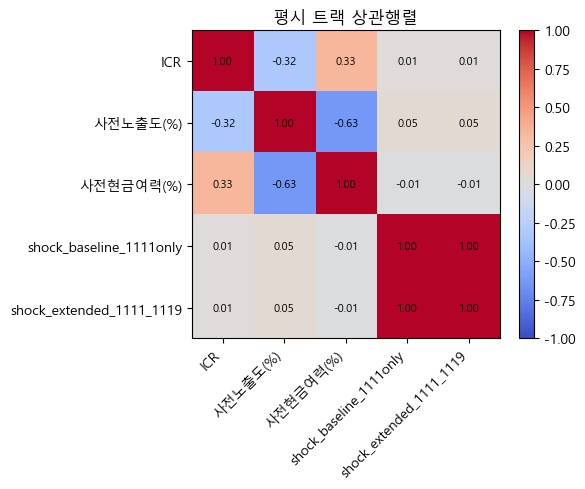

In [4]:
corr_calm = corr_report(calm, "평시")


### 해석

노출도랑 현금여력은 두 트랙 다 -0.53~-0.63 정도로 어느 정도 반대로 움직인다(긴축기 -0.53, 평시 -0.63). 완전히 겹치는 수준(절대값 0.7 이상)은 아니고 방향도 말이 된다 — 단기부채 비중 높은 업종일수록 유동성이 빡빡한 편이니까.

shock_baseline이랑 shock_extended는 거의 같은 변수다(r≈1.0). 예상했던 거고, 회귀엔 어차피 하나만 넣으면 됨.

원자재충격은 노출도·현금여력이랑 상관이 거의 없다(다 0.06 이하). 통제변수로서는 오히려 좋은 신호 — 핵심변수랑 안 겹친다는 뜻이니까.

## 3. 다중공선성(VIF)

실제 회귀에 들어가는 시간가변 변수들(`Post×사전노출도`, `Post×사전현금여력`, `shock_baseline_1111only`)을 기준으로 VIF를 계산한다. 업종·연도 고정효과(더미)는 통상적인 VIF 진단 대상에 포함하지 않는다(6번 노트북의 반도체 통제변수 VIF 계산과 같은 방식).

### 판정 기준 (경험적 관행 — 공식·절대적 기준 아님, 검토8원칙 4번 참고)
- VIF < 5: 다중공선성 문제 없음
- 5 ≤ VIF < 10: 주의 필요
- VIF ≥ 10: 심각한 다중공선성, 변수 제거·결합 고려

In [5]:
def vif_report(df, cols, label):
    X = sm.add_constant(df[cols].dropna())
    rows = []
    for i, col in enumerate(X.columns):
        if col == "const":
            continue
        rows.append({"변수": col, "VIF": variance_inflation_factor(X.values, i)})
    out = pd.DataFrame(rows)
    print(f"=== {label} 트랙 VIF ===")
    display(out.round(3))
    return out

vif_cols = ["Post×사전노출도", "Post×사전현금여력", "shock_baseline_1111only"]

vif_tight = vif_report(tight, vif_cols, "긴축기")


=== 긴축기 트랙 VIF ===


,변수,VIF
0,Post×사전노출도,2.8500
1,Post×사전현금여력,2.8510
2,shock_baseline_1111only,1.0010


In [6]:
vif_calm = vif_report(calm, vif_cols, "평시")


=== 평시 트랙 VIF ===


,변수,VIF
0,Post×사전노출도,2.3450
1,Post×사전현금여력,2.3800
2,shock_baseline_1111only,1.0330


### 해석

VIF 세 개 다 5 밑이다(1.0~2.9) — 다중공선성은 문제없다고 봐도 될 듯. 상관관계에서 노출도-현금여력이 좀 겹쳤는데도 VIF가 안전하게 나온 이유는, 실제로 회귀에 들어가는 게 원래 값이 아니라 Post랑 곱한 상호작용항이기 때문이다. Post=0인 절반은 어차피 두 상호작용항이 다 0이니까 그만큼 상관이 약해지는 것.

9번은 이걸로 통과.

## 4. ICR 분포 및 변환 후보 비교

원자료 그대로 / winsorize(1%, 99%) / asinh 세 가지를 만들어서 분포를 비교한다.

- **winsorize**: 1%, 99% 분위수 밖의 값을 그 분위수 값으로 눌러서 극단값의 영향을 줄임
- **asinh(x) = ln(x + sqrt(x²+1))**: 로그변환과 비슷하게 압축하지만 음수·0도 그대로 다룰 수 있음(ICR에 음수 관측치가 있어서 log는 못 씀)

In [7]:
def make_variants(df):
    out = df.copy()
    lo, hi = out["ICR"].quantile([0.01, 0.99])
    out["ICR_winsor"] = out["ICR"].clip(lower=lo, upper=hi)
    out["ICR_asinh"] = np.arcsinh(out["ICR"])
    return out, lo, hi

tight_v, tight_lo, tight_hi = make_variants(tight)
calm_v,  calm_lo,  calm_hi  = make_variants(calm)

print(f"긴축기 winsorize 경계: [{tight_lo:.2f}, {tight_hi:.2f}]")
print(f"평시   winsorize 경계: [{calm_lo:.2f}, {calm_hi:.2f}]")

desc_tight = tight_v[["ICR", "ICR_winsor", "ICR_asinh"]].describe().T
desc_calm  = calm_v[["ICR", "ICR_winsor", "ICR_asinh"]].describe().T
desc_tight["skew"] = tight_v[["ICR", "ICR_winsor", "ICR_asinh"]].skew()
desc_calm["skew"]  = calm_v[["ICR", "ICR_winsor", "ICR_asinh"]].skew()

print("=== 긴축기 ===")
display(desc_tight.round(3))
print("=== 평시 ===")
display(desc_calm.round(3))


긴축기 winsorize 경계: [-722.26, 8287.63]
평시   winsorize 경계: [-701.21, 10842.55]
=== 긴축기 ===


,count,mean,std,min,25%,50%,75%,max,skew
ICR,240.0000,824.7160,"1,629.2070",-963.0000,285.6250,458.8500,738.4500,"13,480.3000",5.1410
ICR_winsor,240.0000,784.0510,"1,342.7730",-722.2630,285.6250,458.8500,738.4500,"8,287.6280",3.9730
ICR_asinh,240.0000,6.0780,3.3600,-7.5630,6.3480,6.8220,7.2970,10.2020,-3.0920


=== 평시 ===


,count,mean,std,min,25%,50%,75%,max,skew
ICR,200.0000,"1,071.2200","3,157.8610","-2,655.1000",341.0250,534.9000,834.9250,"30,658.3000",7.9070
ICR_winsor,200.0000,892.3470,"1,589.6610",-701.2110,341.0250,534.9000,834.9250,"10,842.5470",4.5430
ICR_asinh,200.0000,6.2910,3.3490,-8.5770,6.5250,6.9750,7.4200,11.0240,-3.3830


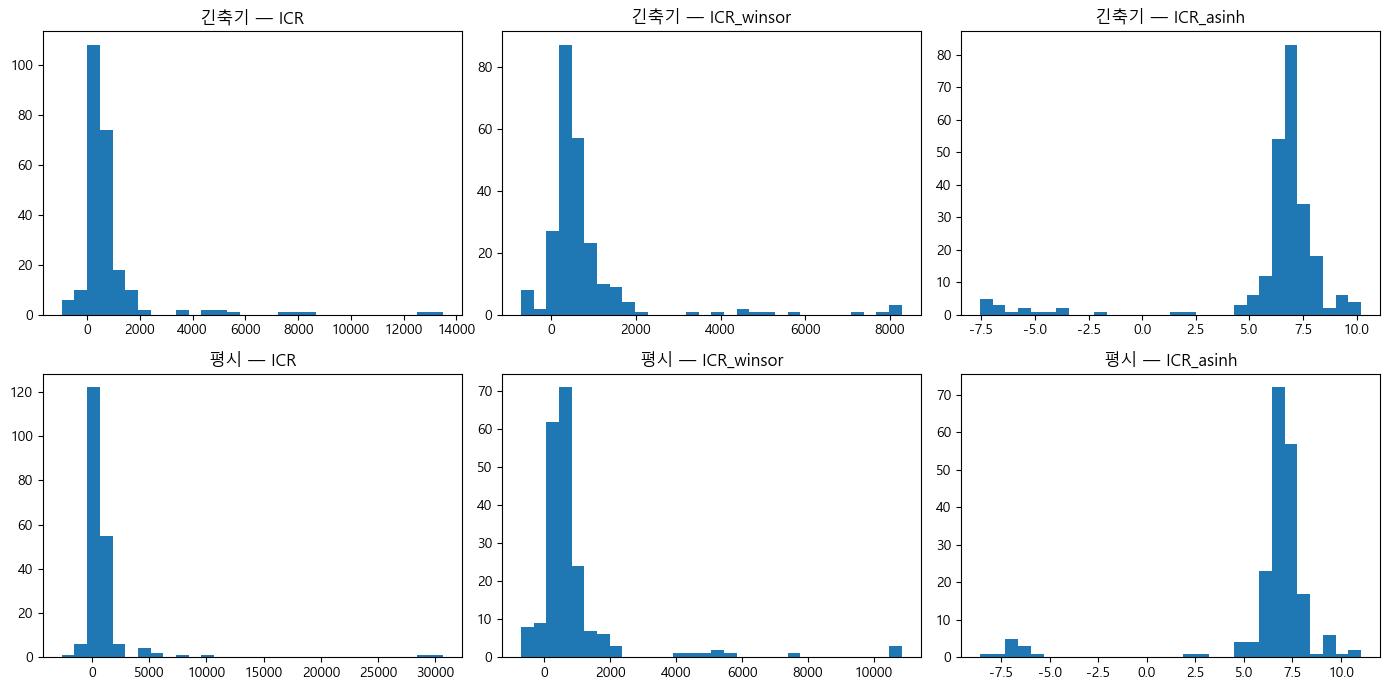

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for row, (df, label) in enumerate([(tight_v, "긴축기"), (calm_v, "평시")]):
    for col, var in enumerate(["ICR", "ICR_winsor", "ICR_asinh"]):
        axes[row, col].hist(df[var].dropna(), bins=30)
        axes[row, col].set_title(f"{label} — {var}")
plt.tight_layout()
plt.show()


### 해석

원자료 왜도가 꽤 크다(긴축기 +5.14, 평시 +7.91) — 이 정도면 변환 없이 쓰기는 어렵겠다 싶은 수준.

winsorize는 왜도를 절반 정도 줄여주는데 방향은 그대로 +다. asinh는 왜도 절대값은 더 많이 줄이는데 부호가 -로 뒤집힌다 — 이게 좀 의외였다. 원자료·winsorize는 오른쪽으로 긴 꼬리(담배처럼 엄청 큰 값들) 때문에 왜도가 큰 건데, asinh가 그 큰 값들을 너무 세게 눌러버리니까 이번엔 반대로 음수 ICR(적자기업) 쪽이 두드러지는 모양이 된 것.

그러니까 asinh가 "왜도 숫자만" 보면 제일 나아 보이지만, 왜곡 방향이 바뀐다는 걸 감안 안 하고 그냥 고르면 안 될 것 같다. 셋 다 완벽하진 않고, 최종 선택은 세 버전으로 실제 회귀를 돌려서 계수가 얼마나 흔들리는지 보고 정하는 게 나을 듯.

## 5. 정리

- 9번(다중공선성): 통과. VIF 다 5 밑, 노출도-현금여력 상관은 있지만 상호작용항 단계에선 문제 안 됨. shock_baseline/extended는 하나만 쓰면 됨.
- 10번(ICR 변환): 원자료 왜도 심하다는 건 확인됐는데 winsorize냐 asinh냐는 아직 못 정함 — asinh가 왜도는 더 줄이지만 방향이 반대로 뒤집히는 트레이드오프가 있어서, 실제 회귀 돌려보고 결정하기로.
- 다음: 11·12번(반도체5개 Δ이상치, ICR분해).


## 6. 부록: 고정효과 후 회귀 진단 (2026-10-01 추가)

위 1~5절은 변수·ICR 분포 점검이고, 이 부록은 **실제 기본모형(ICR ~ Post×사전노출도 + 업종FE + 연도FE, 업종 군집 표준오차)을 돌린 뒤의 진단**이다. 3절 VIF를 고정효과 포함으로 다시 계산하고(6-2), 잔차 정규성·표준오차 종류·자기상관·검정력·leave-one-out·소표본 보정을 확인한다. 진단 설명용이며 좋은 결과를 고르거나 모형을 바꾸려는 것이 아니다.

- 6-8(wild cluster bootstrap)은 직접 구현한 **개념 시연**이다. 정식 14번 작업(검증된 도구, boottest 원문 확인)이 아니다.
- 6-9는 시기(Post 정의)를 정할 때 참고하는 **탐색용 민감도**이며, p값이 좋은 정의를 고르는 근거가 아니다.
- 이 부록의 셀은 위 1~5절과 독립이며 변수 이름이 겹치므로 맨 아래에서 위로 다시 돌릴 때는 순서대로 실행한다.

In [9]:
import numpy as np, pandas as pd, statsmodels.api as sm, statsmodels.formula.api as smf
from scipy import stats
import warnings; warnings.filterwarnings("ignore")
pd.reset_option("display.float_format")   # 위 1~5절에서 바꾼 표시 형식을 되돌림(숫자는 동일)

PANEL = str(PROCESSED / "재무_원자재_병합패널.csv")
d = pd.read_csv(PANEL, encoding="utf-8-sig").rename(columns={
    "사전노출도(%)": "exp", "Post×사전노출도": "px", "Post×사전현금여력": "pc",
    "업종코드": "code", "연도": "year", "shock_baseline_1111only": "shock"})
d = d.sort_values(["code", "year"]).reset_index(drop=True)
print(d.shape, d.code.nunique(), "업종", sorted(d.year.unique()))

def fit_cluster(formula, df):
    return smf.ols(formula, df).fit(cov_type="cluster",
        cov_kwds={"groups": df.code, "use_correction": True, "df_correction": True}, use_t=True)

m = fit_cluster("ICR ~ px + C(code) + C(year)", d)
print(f"기본모형 재현: beta={m.params['px']:.4f}, SE={m.bse['px']:.4f}, p={m.pvalues['px']:.4f}, "
      f"95%CI=[{m.conf_int().loc['px',0]:.1f}, {m.conf_int().loc['px',1]:.1f}], N={int(m.nobs)}")

(240, 16) 40 업종 [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
기본모형 재현: beta=53.6646, SE=40.1988, p=0.1896, 95%CI=[-27.6, 135.0], N=240


### 6-1. 기본모형 재현 확인
예비추정 노트북의 값(β=53.6646, SE=40.1988, p=0.1896)이 그대로 재현되면 이후 진단이 같은 모형 위에서 이뤄진 것이다.

### 6-2. 다중공선성: 고정효과 전 vs 후 VIF

**한 내용**: 10번 노트북은 VIF를 고정효과(업종·연도 평균 제거) 없이 계산했다. 실제 회귀는 고정효과를 포함하므로, 업종·연도 평균을 제거한(two-way demeaned) 변수로 VIF를 다시 계산한다.

**과정**: Post×노출도, Post×현금여력, 원자재 충격 세 변수에 대해 각각 나머지로 회귀한 R²에서 VIF=1/(1-R²)을 구한다.

In [10]:
def vif(df, cols):
    out = {}
    for c in cols:
        o = [x for x in cols if x != c]
        r2 = sm.OLS(df[c], sm.add_constant(df[o])).fit().rsquared
        out[c] = round(float(1 / (1 - r2)), 2)
    return out

cols = ["px", "pc", "shock"]
w = d.copy()
for c in cols:
    w[c] = d[c] - d.groupby("code")[c].transform("mean") - d.groupby("year")[c].transform("mean") + d[c].mean()

print("VIF (고정효과 없이, 10번과 동일):", vif(d, cols))
print("VIF (업종·연도 평균 제거 후):    ", vif(w, cols))
print()
print("업종·연도 평균 제거 후 상관행렬")
print(w[cols].corr().round(2))

VIF (고정효과 없이, 10번과 동일): {'px': 2.85, 'pc': 2.85, 'shock': 1.0}
VIF (업종·연도 평균 제거 후):     {'px': 1.4, 'pc': 1.4, 'shock': 1.0}

업종·연도 평균 제거 후 상관행렬
         px    pc  shock
px     1.00 -0.53  -0.05
pc    -0.53  1.00  -0.01
shock -0.05 -0.01   1.00


**결과·해석**: 고정효과 후 VIF가 오히려 낮아진다(px 1.40, pc 1.40, shock 1.00). 이 상태에서 px–pc 상관은 -0.53으로 노출도–현금여력 원래 상관과 같다(1/(1-0.53²)≈1.39). 고정효과 전 VIF(2.85)가 컸던 것은 두 변수가 모두 Post 해에만 값이 생겨 같이 움직이기 때문이다. 결론(VIF<5)은 유지된다.

참고: 10번 노트북의 "상호작용항이라 상관이 약해진다"는 설명은 이 수치와 맞지 않는다.

### 6-3. 잔차의 정규성

**한 내용**: 기본모형 잔차의 왜도·첨도와 Jarque-Bera 검정, 그리고 ICR을 winsorize·asinh로 바꿨을 때 잔차 모양이 어떻게 달라지는지 본다. (변환 선택을 위한 것이 아님)

In [11]:
r = smf.ols("ICR ~ px + C(code) + C(year)", d).fit().resid
print(f"원자료 ICR   : 왜도 {stats.skew(r):.2f}, 첨도 {stats.kurtosis(r)+3:.1f} (정규=3), JB p={stats.jarque_bera(r)[1]:.2g}")

lo, hi = d.ICR.quantile([.01, .99])
variants = {"winsorize(1%/99%)": d.ICR.clip(lo, hi), "asinh(ICR/100)": np.arcsinh(d.ICR / 100)}
for name, y in variants.items():
    tmp = d.assign(_y=y)
    rr = smf.ols("_y ~ px + C(code) + C(year)", tmp).fit().resid
    print(f"{name:18s}: 왜도 {stats.skew(rr):.2f}, 첨도 {stats.kurtosis(rr)+3:.1f}")

원자료 ICR   : 왜도 1.24, 첨도 20.8 (정규=3), JB p=0
winsorize(1%/99%) : 왜도 1.00, 첨도 23.0
asinh(ICR/100)    : 왜도 -2.10, 첨도 12.0


**결과·해석**: 원자료 잔차는 왜도 1.24, 첨도 20.8로 꼬리가 매우 두껍다. 변환을 해도 두꺼운 꼬리는 사라지지 않는다. 정규성이 성립하지 않으므로 일반 p값에만 의존하지 말고 소표본 보정(6-8)을 병행해야 한다. 변환 선택은 미결정 항목이다.

### 6-4. 등분산성과 표준오차 종류

**한 내용**: 업종별 잔차의 크기가 비슷한지 보고, 일반·이분산 로버스트·업종 군집 표준오차를 비교한다.

**용어**: 일반 표준오차는 모든 관측의 오차 크기가 같다고 가정한다. **HC1**은 관측마다 오차 크기가 달라도 맞도록 보정한 표준오차(이분산 로버스트, 표본 수 보정 포함)이고, **업종 군집 표준오차**는 같은 업종의 여러 해 오차가 서로 닮아도 되도록 업종 단위로 묶어 계산한 표준오차다.

In [12]:
d["res"] = r
sd = d.groupby("업종").res.std().sort_values(ascending=False)
print("업종별 잔차 표준편차 상위 5:", sd.head(5).round(0).to_dict())
print(f"중앙값 {sd.median():.0f}, 최소 {sd.min():.0f}, 최대/최소 약 {sd.max()/sd.min():.0f}배")

classical = smf.ols("ICR ~ px + C(code) + C(year)", d).fit()
hc1 = smf.ols("ICR ~ px + C(code) + C(year)", d).fit(cov_type="HC1")
print(f"\npx 표준오차: 일반 {classical.bse['px']:.1f} | HC1 {hc1.bse['px']:.1f} | 업종 군집 {m.bse['px']:.1f}")

업종별 잔차 표준편차 상위 5: {'담배': 3886.0, '반도체': 2566.0, '통신기기': 2539.0, '석유정제': 705.0, '전지': 625.0}
중앙값 304, 최소 91, 최대/최소 약 43배

px 표준오차: 일반 30.4 | HC1 38.2 | 업종 군집 40.2


**결과·해석**: 업종별 잔차 SD가 최대 약 43배 차이난다(담배·반도체·통신기기가 매우 큼). 일반 표준오차(30.4)는 군집 표준오차(40.2)보다 약 25% 작아서 그대로 쓰면 p값이 실제보다 좋게 나온다. 군집 로버스트 표준오차는 사실상 필수이다.

### 6-5. 잔차의 자기상관

**한 내용**: 같은 업종 안에서 이전 해 잔차와 올해 잔차의 상관을 본다.

In [13]:
d["lag"] = d.groupby("code").res.shift(1)
print(f"업종 내 잔차 1기 상관: {d[['res', 'lag']].corr().iloc[0, 1]:.2f}")

업종 내 잔차 1기 상관: 0.10


**결과·해석**: 1기 상관이 0.10으로 약하다. 그래도 업종 군집 표준오차는 업종 내 임의의 상관을 허용하므로 안전하다.

### 6-6. 처치강도(노출도 분산)와 검정력

**한 내용**: 사전노출도의 분포, 그리고 현재 표준오차에서 검정력 80%·유의수준 5%로 안정적으로 잡을 수 있는 최소 효과(MDE)를 정규 근사로 계산한다.

**용어**: **MDE**(최소 검출 가능 효과)는 "진짜 효과가 이 크기 이상이면 80% 확률로 유의하게 잡아낸다"는 효과 크기이다. (1.96+0.84)×표준오차는 유의수준 5%·검정력 80%라는 **관행적 설정**에 따른 정규 근사이며 공식 기준이 아니다.

In [14]:
u = d.drop_duplicates("code")
print(f"사전노출도: 범위 {u.exp.min():.2f}~{u.exp.max():.2f}, 표준편차 {u.exp.std():.2f}, 중앙값 {u.exp.median():.2f}")
mde = (1.96 + 0.84) * m.bse["px"]
print(f"MDE = (1.96+0.84) x SE = {mde:.0f}  (현재 beta={m.params['px']:.1f})")
print(f"노출도 1표준편차 차이의 ICR 효과 약 {mde*u.exp.std():.0f}  (ICR 중앙값 {d.ICR.median():.0f})")

사전노출도: 범위 2.12~21.44, 표준편차 4.23, 중앙값 9.66
MDE = (1.96+0.84) x SE = 113  (현재 beta=53.7)
노출도 1표준편차 차이의 ICR 효과 약 476  (ICR 중앙값 459)


**결과·해석**: 현재 표준오차로는 노출도 1%p당 약 113 이상의 큰 효과여야 안정적으로 검출된다(β̂=53.7은 그 절반). 작거나 중간 효과는 이 표본으로 구별하기 어렵다. 따라서 "유의하지 않음 ≠ 효과 없음"이다. (정규 근사이며 단순화한 값)

### 6-7. 업종 하나씩 제외 (leave-one-out)

**한 내용**: 40개 업종을 하나씩 빼고 같은 모형을 다시 추정해 β가 얼마나 흔들리는지 본다. 전부 보고하는 것이 원칙이며 일부만 골라 보여 주지 않는다.

In [15]:
rows = []
for c in d.code.unique():
    s = d[d.code != c]
    mm = fit_cluster("ICR ~ px + C(code) + C(year)", s)
    rows.append((d[d.code == c].업종.iloc[0], mm.params["px"], mm.pvalues["px"]))
L = pd.DataFrame(rows, columns=["제외업종", "beta", "p"])
print(f"beta 범위 {L.beta.min():.1f} ~ {L.beta.max():.1f}, 부호 반전 {int((L.beta < 0).sum())}회 (기준 beta={m.params['px']:.1f})")
print(L.assign(편차=(L.beta - m.params['px']).abs()).sort_values("편차", ascending=False).head(8).round(2).to_string(index=False))

beta 범위 28.2 ~ 65.8, 부호 반전 0회 (기준 beta=53.7)
 제외업종  beta    p    편차
  반도체 28.16 0.43 25.51
 통신기기 30.46 0.39 23.21
   담배 65.81 0.10 12.14
 석유정제 60.35 0.15  6.68
   주조 59.84 0.21  6.18
디스플레이 58.77 0.19  5.10
   목재 57.49 0.18  3.83
   섬유 57.47 0.17  3.81


**결과·해석**: 부호가 뒤집히는 경우는 없다. 반도체(28.2)·통신기기(30.5)를 빼면 β가 줄고, 담배(65.8)·석유정제(60.4)를 빼면 커진다. 한 업종 때문에 결론이 바뀌지는 않지만 반도체 계열이 β를 끌어올리는 방향이다. Cook's distance는 아직 하지 않았다.

### 6-8. wild cluster bootstrap 시연 (개념 시연)

**한 내용**: 군집이 40개로 적을 때 쓰는 wild cluster bootstrap-t(Rademacher 가중: 각 업종의 잔차 전체에 +1 또는 -1을 같은 확률로 곱해 새 표본을 만드는 방식, Cameron·Gelbach·Miller 2008이 제안. 본문에서 확인한 것은 이 가중과 bootstrap-t 구조까지이고, 아래의 "귀무가설을 가정한 잔차 사용" 같은 구현 세부는 이 노트북에서 해당 문헌으로 확인하지 않은 일반적 관행이다)를 직접 구현해, 일반 군집 p값과 비교한다.

**주의**: 직접 구현이며 boottest 등 검증된 도구와 대조하지 않았다. 정식 14번 작업이 아니다.

In [16]:
rng = np.random.default_rng(1)
codes, years = d.code.values, d.year.values
N, G = len(d), d.code.nunique()
K = 1 + (G - 1) + (d.year.nunique() - 1) + 1   # 상수 + 업종더미 + 연도더미 + px (statsmodels 보정과 동일)

def twoway(v):
    s = pd.Series(v)
    return (s - s.groupby(codes).transform("mean") - s.groupby(years).transform("mean") + s.mean()).values

pxd = twoway(d.px.values); denom = (pxd ** 2).sum()
def tstat(yd):
    b = (pxd * yd).sum() / denom
    e = yd - b * pxd
    sc = pd.Series(pxd * e).groupby(codes).sum().values
    se = np.sqrt((sc ** 2).sum()) / denom * np.sqrt((G / (G - 1)) * ((N - 1) / (N - K)))
    return b / se

yd = twoway(d.ICR.values)
t0 = tstat(yd)
fe_resid = yd                                   # FE만 넣은 모형(귀무)의 잔차
fitted0 = d.ICR.values - fe_resid               # FE만 넣은 모형의 적합값
uc = np.unique(codes); idx = {c: np.where(codes == c)[0] for c in uc}

B, cnt = 4999, 0
for _ in range(B):
    w_ = rng.choice([-1, 1], size=G)
    wi = np.zeros(N)
    for k, c in enumerate(uc): wi[idx[c]] = w_[k]
    if abs(tstat(twoway(fitted0 + wi * fe_resid))) >= abs(t0): cnt += 1

print(f"t={t0:.3f} | 일반 군집 p(t, df={G-1}) = {2*(1-stats.t.cdf(abs(t0), G-1)):.3f} | wild cluster bootstrap p = {cnt/B:.3f} (B={B})")

t=1.335 | 일반 군집 p(t, df=39) = 0.190 | wild cluster bootstrap p = 0.225 (B=4999)


**결과·해석**: 일반 군집 p값 0.190, wild cluster bootstrap p값 0.225로 결론(비유의)은 같다. 소표본 보정을 해도 결과가 뒤집히지 않는다는 개념 확인이며, 확정은 정식 14번에서 한다.

### 6-9. 부록: 이중차분 2×2 예시와 Post 정의 민감도 (탐색용)

**한 내용**: (a) 노출도 중앙값으로 두 그룹을 나눈 단순 이중차분 예시, (b) Post 정의에 따라 β가 얼마나 달라지는지.

**주의**: (b)는 시기를 정할 때 "자의성이 얼마나 큰지" 보여 주기 위한 것이다. **p값이 좋은 정의를 고르는 근거가 아니다.** 시기는 결과와 무관한 기준(금리 이력, 사전기간 내 다른 사건)으로 먼저 정하고 나머지는 강건성으로 모두 보고해야 한다.

In [17]:
med = u.exp.median()
d["grp"] = np.where(d.exp >= med, "고", "저")
pre = d[d.year.between(2018, 2020)]; post = d[d.year.isin([2022, 2023])]
t2 = pd.DataFrame({"사전평균": pre.groupby("grp").ICR.mean(), "Post평균": post.groupby("grp").ICR.mean()}).round(1)
t2["변화"] = t2["Post평균"] - t2["사전평균"]
print(f"(a) 노출도 중앙값 {med:.2f} 기준 2x2 (평균 ICR)"); print(t2)
print(f"이중차분 = {t2.loc['고', '변화'] - t2.loc['저', '변화']:.1f}")

print("\n(b) Post 정의별 beta (같은 모형, 업종 군집 SE) : (beta, SE, p, N)")
def beta_of(df, col):
    tmp = df.assign(px2=df[col] * df.exp)
    mm = fit_cluster("ICR ~ px2 + C(code) + C(year)", tmp)
    return round(float(mm.params["px2"]), 1), round(float(mm.bse["px2"]), 1), round(float(mm.pvalues["px2"]), 3), int(mm.nobs)
d["P_A"] = (d.year >= 2022).astype(int); d["P_C"] = (d.year >= 2021).astype(int); d["P_D"] = (d.year >= 2023).astype(int)
print("A. Post=2022~ (현재)  ", beta_of(d, "P_A"))
print("B. 2021년 행 제외     ", beta_of(d[d.year != 2021], "P_A"))
print("C. Post=2021~         ", beta_of(d, "P_C"))
print("D. Post=2023~         ", beta_of(d, "P_D"))

(a) 노출도 중앙값 9.66 기준 2x2 (평균 ICR)
       사전평균  Post평균     변화
grp                       
고     377.8   325.2  -52.6
저    1163.7  1042.0 -121.7
이중차분 = 69.1

(b) Post 정의별 beta (같은 모형, 업종 군집 SE) : (beta, SE, p, N)
A. Post=2022~ (현재)   (53.7, 40.2, 0.19, 240)
B. 2021년 행 제외      (30.0, 45.4, 0.512, 200)
C. Post=2021~          (-11.6, 40.5, 0.777, 240)
D. Post=2023~          (114.9, 54.7, 0.042, 240)


**결과·해석**: (a) 고노출 그룹이 덜 나빠졌다(이중차분 +69.1, β>0과 같은 방향). 저노출 그룹에 반도체·담배가 있어 평균이 끌린다.

(b) 네 정의는 **같은 질문의 대안이 아니다.** A는 2018~2021을 비교 기준으로, 2022~2023을 사후로 본다. **B(2021 행 제외)는 같은 질문에서 전환연도 표본만 뺀 민감도**이다. **C(2021~ Post)는 인상이 시작된 해를 사후로 옮기고, D(2023~ Post)는 이미 금리가 오른 2022년을 비교 기준에 넣어** 비교 구조 자체가 달라진다. 따라서 β의 부호·p값(p 0.04~0.78)이 달라지는 것을 "같은 효과의 추정치가 흔들린다"로만 읽으면 안 되고, D의 p=0.042도 더 좋은 추정이 아니라 다른 비교의 결과이다. 결과를 보고 정의를 고르면 끼워 맞추기가 된다. 2021년은 사전 평균에서는 빠지지만 이 표의 A에서는 Post=0 비교 기준에 들어간다(전환연도).

### 6-10. ICR 변환별 계수 (단위 의존성 예시)

**한 내용**: 대화에서 인용한 "ICR 변환에 따라 β와 p값이 달라진다"는 숫자를 재현 가능하게 저장한다. 같은 모형에서 종속변수만 바꾼다.

**주의**: 변환을 고르기 위한 표가 **아니다.** p값이 좋은 변환을 고르면 끼워 맞추기가 된다. asinh는 나누는 상수에 따라 값이 달라지는 **단위 의존성**을 보이려는 것이다. asinh(ICR)은 이 노트북 4절에서 쓴 정의이다.

In [18]:
lo_, hi_ = d.ICR.quantile([.01, .99])
variants_ = [("원자료", d.ICR), ("winsorize(1%/99%)", d.ICR.clip(lo_, hi_)),
             ("asinh(ICR/100)", np.arcsinh(d.ICR / 100)), ("asinh(ICR) - 4절 정의", np.arcsinh(d.ICR)),
             ("asinh(ICR/1000)", np.arcsinh(d.ICR / 1000))]
rows_ = []
for nm_, y_ in variants_:
    mm_ = fit_cluster("_y ~ px + C(code) + C(year)", d.assign(_y=y_))
    rows_.append((nm_, round(float(mm_.params["px"]), 4), round(float(mm_.bse["px"]), 4), round(float(mm_.pvalues["px"]), 3)))
print(pd.DataFrame(rows_, columns=["종속변수", "beta", "SE", "p"]).to_string(index=False))
print()
print(f"winsorize 경계 [{lo_:.1f}, {hi_:.1f}] | ICR>=100(1배 이상) {int((d.ICR >= 100).sum())}/{len(d)} | ICR<0 {int((d.ICR < 0).sum())}개")

              종속변수    beta      SE     p
               원자료 53.6646 40.1988 0.190
 winsorize(1%/99%) 61.2366 36.9930 0.106
    asinh(ICR/100)  0.0374  0.0495 0.455
asinh(ICR) - 4절 정의  0.0731  0.1262 0.566
   asinh(ICR/1000)  0.0263  0.0178 0.147

winsorize 경계 [-722.3, 8287.6] | ICR>=100(1배 이상) 216/240 | ICR<0 16개


**결과·해석**: 세 변환 모두 β 부호는 양수이다. asinh는 나누는 상수에 따라 p가 0.15~0.57로 움직인다(단위 의존성). winsorize는 단위가 유지되어 해석은 직관적이지만 경계는 관행(1%/99%)이다. 변환 선택(D1)은 이 표의 p값이 아니라 해석 가능성·선행연구 관행·극단값 논리로 한다.

### 6-11. 통제변수를 추가했을 때 계수 변화 (예시)

**한 내용**: 대화에서 인용한 "원자재 충격이나 Post×현금여력을 넣으면 β가 얼마나 움직이나"를 재현 가능하게 저장한다.

**주의**: 어떤 변수를 넣을지 결정하는 근거가 **아니다**(통제변수는 이론적 이유로 정한다). 변수를 추가하면 추정치가 움직인다는 것과 그 크기를 보이는 예시다.

In [19]:
specs_ = [("기본: Post x 노출도", "ICR ~ px + C(code) + C(year)"),
          ("+ 원자재 충격", "ICR ~ px + shock + C(code) + C(year)"),
          ("+ Post x 현금여력", "ICR ~ px + pc + C(code) + C(year)"),
          ("+ 원자재 충격 + Post x 현금여력", "ICR ~ px + pc + shock + C(code) + C(year)")]
for nm_, f_ in specs_:
    mm_ = fit_cluster(f_, d)
    extra_ = {k: (round(float(mm_.params[k]), 2), round(float(mm_.pvalues[k]), 3)) for k in ["pc", "shock"] if k in mm_.params.index}
    print(f"{nm_:32s} px: beta={float(mm_.params['px']):7.2f}, p={float(mm_.pvalues['px']):.3f} | 추가 변수(beta, p): {extra_}")

기본: Post x 노출도                   px: beta=  53.66, p=0.190 | 추가 변수(beta, p): {}
+ 원자재 충격                         px: beta=  54.27, p=0.182 | 추가 변수(beta, p): {'shock': (8.8, 0.715)}
+ Post x 현금여력                    px: beta=  65.46, p=0.149 | 추가 변수(beta, p): {'pc': (3.29, 0.465)}
+ 원자재 충격 + Post x 현금여력           px: beta=  66.45, p=0.132 | 추가 변수(beta, p): {'pc': (3.39, 0.431), 'shock': (9.32, 0.693)}


**결과·해석**: 변수를 추가하면 노출도 β가 53.7에서 54.3~66.5로 움직인다. 추가한 변수의 계수는 모두 유의하지 않다(예: 원자재 충격 8.80, p=0.715; Post×현금여력 3.29, p=0.465). 통제변수 계수는 해석하지 않는다.

### 6-12. 변수 스케일(표준화)이 왜도·정규성·계수 검정에 영향을 주는가

**한 내용**: "변수 단위가 달라서 왜도가 큰 것 아닌가, scaler(표준화·정규화)를 쓰면 어떤가"라는 질문을 숫자로 확인한다. ICR과 Post×노출도를 평균 0·표준편차 1로 바꾸거나(StandardScaler) 0~1로 바꾼(MinMax) 뒤, 왜도·첨도와 기본모형의 t값·p값이 달라지는지 본다.

**주의**: 어떤 변환이나 사양을 고르기 위한 표가 **아니다.** 선형 변환이 검정 결과를 바꾸지 않는다는 것을 보이는 확인이다. 마지막의 업종별 척도 요약은 기술 통계이며 종속변수를 바꾼 회귀를 돌리지 않는다.

In [20]:
from scipy import stats

def zs(s): return (s - s.mean()) / s.std(ddof=0)
def mm01(s): return (s - s.min()) / (s.max() - s.min())

rows_ = []
for nm_, yv, xv in [("원자료", d.ICR, d.px),
                    ("표준화(z-score)", zs(d.ICR), zs(d.px)),
                    ("MinMax(0~1)", mm01(d.ICR), mm01(d.px))]:
    tmp_ = d.assign(_y=yv, _x=xv)
    mod_ = fit_cluster("_y ~ _x + C(code) + C(year)", tmp_)
    rows_.append((nm_, round(float(stats.skew(yv)), 3), round(float(stats.kurtosis(yv, fisher=False)), 2),
                  round(float(mod_.tvalues["_x"]), 4), round(float(mod_.pvalues["_x"]), 4)))
print(pd.DataFrame(rows_, columns=["종속·설명변수 척도", "ICR 왜도", "ICR 첨도", "x의 t값", "p"]).to_string(index=False))

r_ = smf.ols("ICR ~ px + C(code) + C(year)", d).fit().resid
rz_ = smf.ols("_y ~ _x + C(code) + C(year)", d.assign(_y=zs(d.ICR), _x=zs(d.px))).fit().resid
print(f"\n잔차 왜도: 원자료 {stats.skew(r_):.3f} | 표준화 {stats.skew(rz_):.3f}   잔차 첨도: {stats.kurtosis(r_, fisher=False):.2f} | {stats.kurtosis(rz_, fisher=False):.2f}")

  종속·설명변수 척도  ICR 왜도  ICR 첨도  x의 t값      p
         원자료   5.109   33.94  1.335 0.1896
표준화(z-score)   5.109   33.94  1.335 0.1896
 MinMax(0~1)   5.109   33.94  1.335 0.1896



잔차 왜도: 원자료 1.243 | 표준화 1.243   잔차 첨도: 20.81 | 20.81


**결과·해석**: 표준화와 MinMax는 모두 값에 상수를 곱하고 더하는 **선형 변환**이다. 왜도·첨도는 단위에 무관한 모양 통계라서 변하지 않고, 회귀의 t값과 p값도 같다(계수의 크기만 단위가 바뀐다). 따라서 scaler는 왜도·정규성·선형성 문제를 해결하지 못한다. scaler가 의미 있는 경우는 계수 크기를 서로 비교하거나 규제(ridge·lasso) 같은 모형을 쓸 때다.

In [21]:
g_ = d.copy()
pre_ = g_[g_.year.between(2018, 2020)].groupby("code").ICR.agg(["mean", "std"])
print("업종별 사전기간(2018~2020) ICR 평균: 최소 %.0f, 중앙 %.0f, 최대 %.0f" % (pre_["mean"].min(), pre_["mean"].median(), pre_["mean"].max()))
sd_all_ = g_.groupby("code").ICR.std()
print("업종별 ICR 표준편차(전 기간 6개 관측): 최소 %.0f, 중앙 %.0f, 최대 %.0f, 최대/최소 약 %.0f배" % (sd_all_.min(), sd_all_.median(), sd_all_.max(), sd_all_.max() / sd_all_.min()))
print("사전 평균 ICR이 100(1배) 미만인 업종 수:", int((pre_["mean"] < 100).sum()))

업종별 사전기간(2018~2020) ICR 평균: 최소 -323, 중앙 438, 최대 6139
업종별 ICR 표준편차(전 기간 6개 관측): 최소 47, 중앙 237, 최대 4081, 최대/최소 약 86배
사전 평균 ICR이 100(1배) 미만인 업종 수: 4


**결과·해석**: 문제가 되는 것은 변수 간 단위 차이가 아니라 **업종마다 ICR의 수준과 변동 크기가 다르다**는 점이다. 이는 선형 scaler로 해결되지 않는다. 이를 다루는 방법은 이분산 로버스트 표준오차, 군집 표준오차, 업종별 기준으로 ICR을 상대화하는 변환 등이다. 단 상대화(업종별 사전기간 평균으로 나누기 등)는 기준이 0 근처이거나 음수이면 정의가 깨지고, D1에서 (가) 원자료를 주 결과로 정했으므로 강건성 후보(선택)로만 둔다. 이 노트북에서는 실행하지 않았다.